In [20]:
# ============================================================
# CLUSTERING 3: JERÁRQUICO
# ============================================================
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
# 2. Cargar los datos
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
url = '/content/drive/MyDrive/nacimientos/Serie_Nacimientos_2001_2019.csv'
df = pd.read_csv(url, sep=";")
df.head()

,MES_NAC,ANO_NAC,SEXO,TIPO_PARTO,TIPO_ATEN,PARTO_LOCAL,SEMANAS,RANGO_PESO,TALLA,GRUPO_ETARIO_PADRE,...,GRUPO_ETARIO_MADRE,EST_CIV_MADRE,CURSO_MADRE,NIVEL_MADRE,ACTIV_MADRE,OCUPA_MADRE,CATEG_MADRE,NACIONALIDAD_MADRE,REGION_RESIDENCIA,GLOSA_REGION_RESIDENCIA
0,1,2001,1,1,1,1,NaN,1500 - 2499,46.0,30 A 34 AÑOS,...,30 A 34 AÑOS,2.0,4.0,1.0,1.0,3,4.0,C,13.0,Metropolitana de Santiago
1,1,2001,1,1,1,1,NaN,3000 - 3999,50.0,30 A 34 AÑOS,...,30 A 34 AÑOS,2.0,4.0,2.0,0.0,2,0.0,C,13.0,Metropolitana de Santiago
2,1,2001,1,1,1,1,NaN,3000 - 3999,53.0,30 A 34 AÑOS,...,30 A 34 AÑOS,2.0,4.0,2.0,0.0,2,0.0,C,13.0,Metropolitana de Santiago
3,1,2001,1,1,1,1,24.0,<1500,29.0,25 A 29 AÑOS,...,15 A 19 AÑOS,1.0,2.0,2.0,0.0,3,0.0,C,13.0,Metropolitana de Santiago
4,1,2001,1,1,1,1,24.0,<1500,30.0,40 A 44 AÑOS,...,35 A 39 AÑOS,2.0,2.0,2.0,0.0,2,0.0,C,3.0,De Atacama


In [13]:
variables = [
    "SEMANAS",
    "TALLA"
]

df_num = df[variables].dropna()

scaler = StandardScaler()


In [14]:
# ------------------------------------------------------------
# 1. Tomar una muestra para que sea rápido
# ------------------------------------------------------------
df_sample_hier = df_num.sample(n=5000, random_state=42)  # df_num = datos numéricos (SEMANAS, TALLA)
X_hier = scaler.fit_transform(df_sample_hier)            # usamos el mismo scaler de antes

print("Dimensiones muestra jerárquico:", X_hier.shape)


Dimensiones muestra jerárquico: (5000, 2)


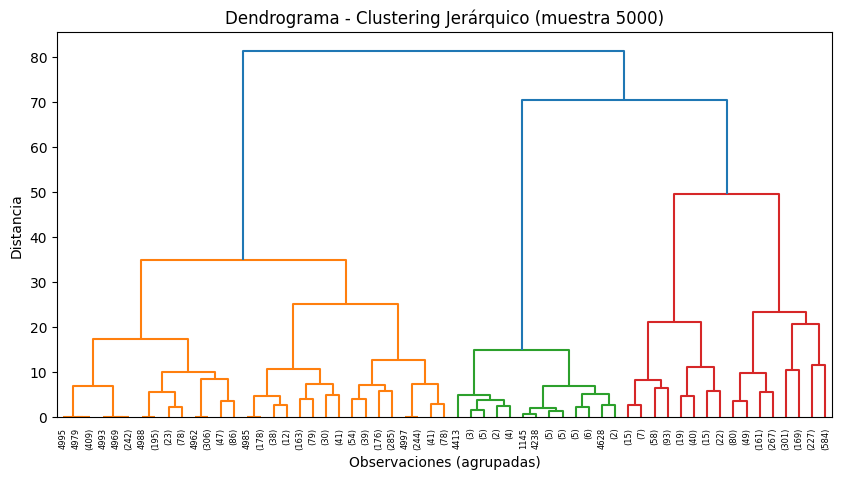

In [15]:
# ------------------------------------------------------------
# 2. Dendrograma (para ver estructura)
# ------------------------------------------------------------
Z = linkage(X_hier, method="ward")  # ward = minimiza varianza dentro de los grupos

plt.figure(figsize=(10, 5))
dendrogram(
    Z,
    truncate_mode="level",  # truncar para que no sea gigante
    p=5                     # niveles visibles del árbol
)
plt.title("Dendrograma - Clustering Jerárquico (muestra 5000)")
plt.xlabel("Observaciones (agrupadas)")
plt.ylabel("Distancia")
plt.show()


In [17]:
# ------------------------------------------------------------
# 3. Elegir número de clusters (puedes ajustar este valor)
#    Revisa el dendrograma y elige un número razonable, por ejemplo 3.
# ------------------------------------------------------------
n_clusters = 3  # cámbialo si el dendrograma sugiere otro

hier = AgglomerativeClustering(
    n_clusters=n_clusters,
    metric="euclidean",
    linkage="ward"
)


labels_hier = hier.fit_predict(X_hier)


In [18]:
# ------------------------------------------------------------
# 4. Métricas de evaluación
# ------------------------------------------------------------
silhouette_hier = silhouette_score(X_hier, labels_hier)
davies_hier = davies_bouldin_score(X_hier, labels_hier)
calinski_hier = calinski_harabasz_score(X_hier, labels_hier)

print("\nCLUSTERING JERÁRQUICO - MÉTRICAS:")
print("Número de clusters:", n_clusters)
print("Silhouette Score:", silhouette_hier)
print("Davies-Bouldin:", davies_hier)
print("Calinski-Harabasz:", calinski_hier)



CLUSTERING JERÁRQUICO - MÉTRICAS:
Número de clusters: 3
Silhouette Score: 0.3825220708096982
Davies-Bouldin: 0.772698833891665
Calinski-Harabasz: 3452.1225937526087


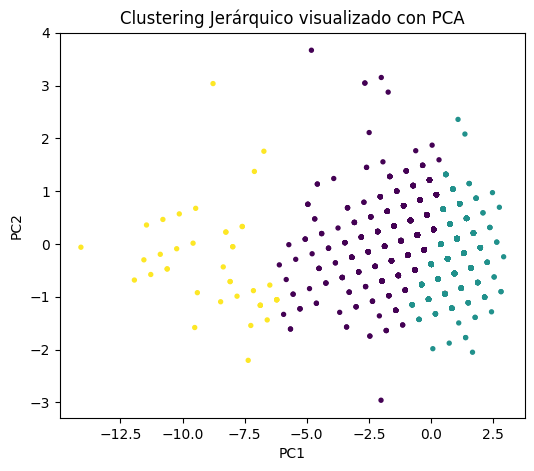

In [21]:
# ------------------------------------------------------------
# 5. Visualización 2D con PCA (opcional pero bonito)
# ------------------------------------------------------------
pca_hier = PCA(n_components=2)
coords_hier = pca_hier.fit_transform(X_hier)

plt.figure(figsize=(6,5))
plt.scatter(coords_hier[:,0], coords_hier[:,1],
            c=labels_hier, cmap="viridis", s=8)
plt.title("Clustering Jerárquico visualizado con PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()